# Day 7 · Seeing the pattern
*Measuring Manuscripts*

You can't see fifty dimensions at once. Dimensionality reduction compresses high-dimensional data (sign shapes, vowels, word counts) to two, so the clusters become visible. The compression distorts, so we read the picture and then question it.

## 1. Setup

In [1]:
!pip install umap-learn scikit-learn --quiet


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3.9 -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Data with real clusters

150 points in 20 dimensions, in three genuine clusters. Treat each point as a sign, a vowel, or a text, whatever.

In [ ]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=150, centers=3, n_features=20, cluster_std=2.5, random_state=0)
print('data:', X.shape)

data: (150, 20)


## 3. PCA: the linear view

Fast, with interpretable axes. It can blur fine structure, but it's hard to mislead with.

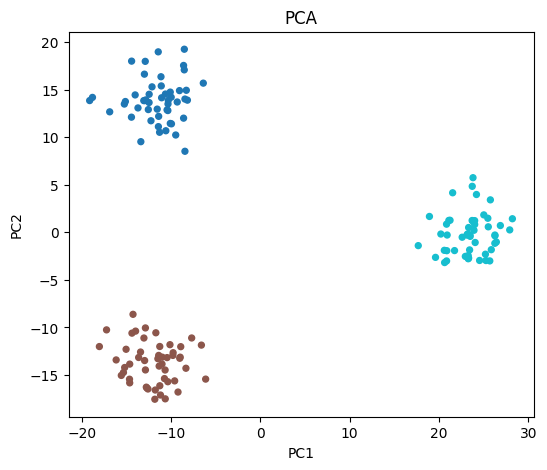

In [4]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
p = pca.fit_transform(X)
plt.figure(figsize=(6, 5))
plt.scatter(p[:, 0], p[:, 1], c=y, cmap='tab10', s=18)
plt.title('PCA'); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.show()

## 4. How much did PCA keep?

Those two axes are a summary, and a summary omits things. The explained-variance ratio says how much of the original structure survived the compression.

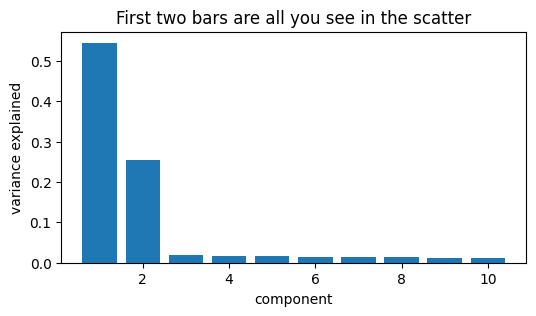

PC1+PC2 keep 80 % of the variance.


In [5]:
full = PCA().fit(X)
plt.figure(figsize=(6, 3))
plt.bar(range(1, 11), full.explained_variance_ratio_[:10])
plt.xlabel('component'); plt.ylabel('variance explained')
plt.title('First two bars are all you see in the scatter'); plt.show()
print('PC1+PC2 keep', round(100 * full.explained_variance_ratio_[:2].sum()), '% of the variance.')

## 4b. What do the PCA axes mean?

Each PCA axis is a fixed recipe of your original features. Read the recipe and you can sometimes name the axis. Here are the features that weigh most heavily on PC1 and PC2: the ones that decide left–right and up–down in the scatter.

In [ ]:
# How each original feature contributes to PC1 and PC2 (the 'loadings')
loadings = pca.components_           # shape: 2 axes x 20 features
for axis, name in [(0, 'PC1'), (1, 'PC2')]:
    order = np.argsort(np.abs(loadings[axis]))[::-1][:3]
    top = ', '.join(f'feature {j} ({loadings[axis][j]:+.2f})' for j in order)
    print(f'{name} is driven most by:', top)

PC1 is driven most by: feature 7 (-0.44), feature 13 (-0.38), feature 3 (-0.34)
PC2 is driven most by: feature 16 (-0.42), feature 15 (-0.40), feature 10 (+0.37)


## 5. UMAP: separating clusters

Nonlinear, and good at pulling clusters apart. But the distances between clusters can be unreliable, so don't read meaning into the gaps.

/usr/local/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


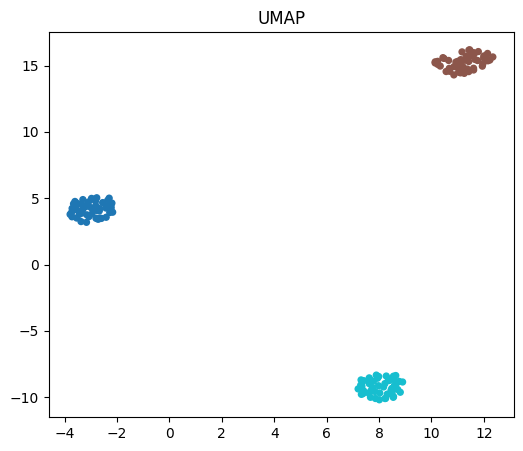

In [7]:
import umap
u = umap.UMAP(random_state=0).fit_transform(X)
plt.figure(figsize=(6, 5))
plt.scatter(u[:, 0], u[:, 1], c=y, cmap='tab10', s=18)
plt.title('UMAP'); plt.show()

## 6. UMAP is sensitive: vary one setting

`n_neighbors` controls how local or global UMAP's view is. Change it and the picture changes. None is the true one. They answer slightly different questions.

/usr/local/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/usr/local/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/usr/local/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


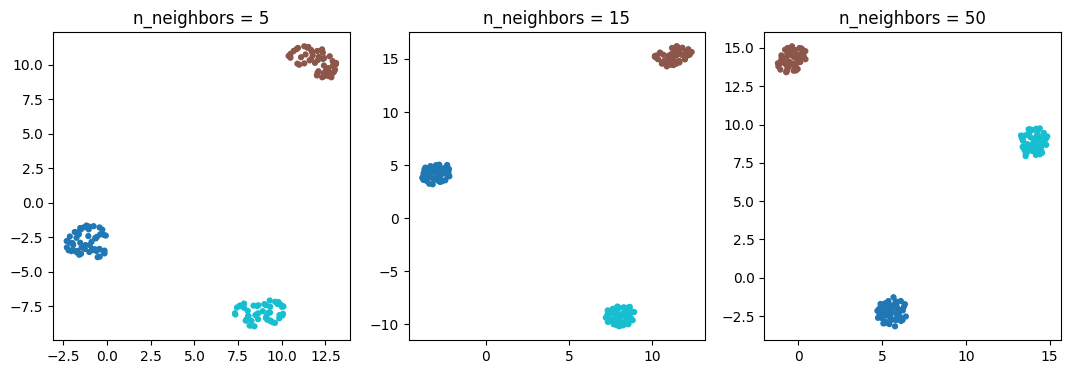

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, nn in zip(axes, [5, 15, 50]):
    emb = umap.UMAP(n_neighbors=nn, random_state=0).fit_transform(X)
    ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap='tab10', s=12)
    ax.set_title(f'n_neighbors = {nn}')
plt.show()

## 7. t-SNE, for comparison

Another nonlinear method. Compare its picture with UMAP's. Where they agree, the structure is more trustworthy.

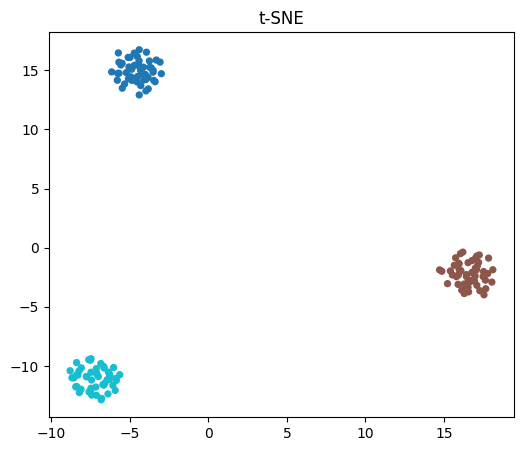

In [9]:
from sklearn.manifold import TSNE
ts = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(X)
plt.figure(figsize=(6, 5))
plt.scatter(ts[:, 0], ts[:, 1], c=y, cmap='tab10', s=18)
plt.title('t-SNE'); plt.show()

## 7b. t-SNE is sensitive too: vary perplexity

`perplexity` is t-SNE's main knob: roughly how many neighbors each point tries to stay close to. Low values stress small local clumps. High values stress broader groups. As with UMAP's `n_neighbors`, no single value is correct.

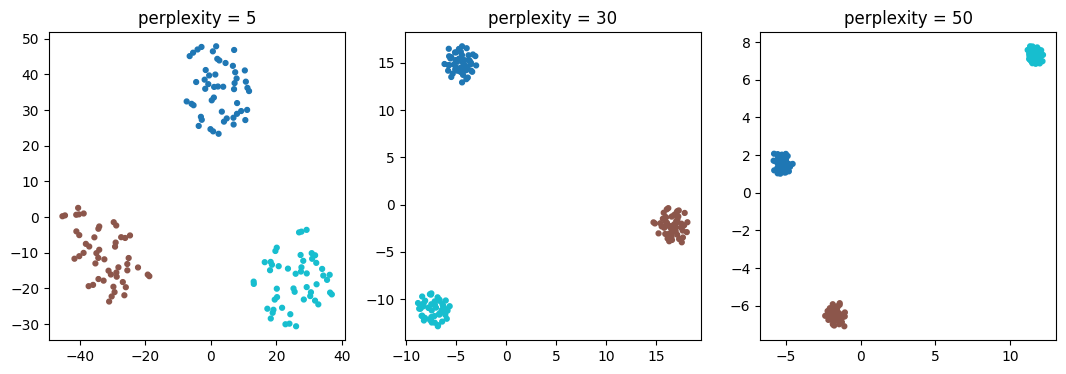

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, perp in zip(axes, [5, 30, 50]):
    emb = TSNE(n_components=2, perplexity=perp, random_state=0).fit_transform(X)
    ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap='tab10', s=12)
    ax.set_title(f'perplexity = {perp}')
plt.show()

## 8. Put a number on the clusters

Eyeballing clusters is subjective. Cluster the embedding automatically and score it against the true labels. A score near 1 means the clustering recovered the real groups.

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
pred = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(u)
print('Adjusted Rand score vs true labels:', round(adjusted_rand_score(y, pred), 2))

Adjusted Rand score vs true labels: 1.0


## 8b. Does the projection help the clustering?

Cluster the raw 20-dimensional data and the 2-D UMAP embedding, and score each against the true labels. If the embedding scores at least as well, the projection kept the structure that matters.

In [12]:
km_raw = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(X)
km_emb = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(u)
print('Adjusted Rand, raw 20-D data:', round(adjusted_rand_score(y, km_raw), 2))
print('Adjusted Rand, 2-D UMAP     :', round(adjusted_rand_score(y, km_emb), 2))
# 1.0 = perfect recovery of the true groups; 0.0 = no better than chance

Adjusted Rand, raw 20-D data: 1.0
Adjusted Rand, 2-D UMAP     : 1.0


## 8c. Hierarchical clustering: let the data pick the number

k-means needs you to name the number of groups. Hierarchical clustering does not: it merges the two closest groups over and over and records the order as a tree. Long vertical jumps in the tree mark natural cut points, where the data resist merging.

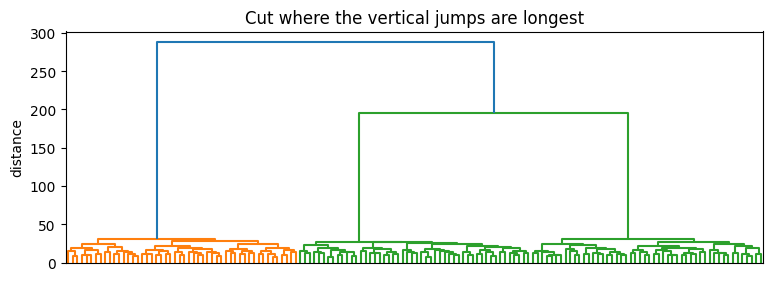

In [13]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
Z = linkage(X, method='ward')
plt.figure(figsize=(9, 3))
dendrogram(Z, no_labels=True)
plt.title('Cut where the vertical jumps are longest'); plt.ylabel('distance'); plt.show()

## 9. Two seeds, two pictures

Run UMAP twice with different random seeds. The clusters are the same, but the spaces between them (the part the eye reads as 'how different') are not. Don't build an argument on the gaps.

/usr/local/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/usr/local/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


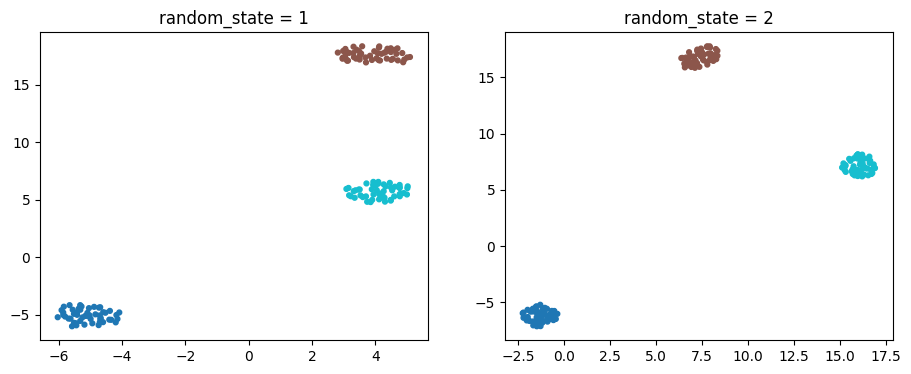

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, seed in zip(axes, [1, 2]):
    emb = umap.UMAP(random_state=seed).fit_transform(X)
    ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap='tab10', s=12)
    ax.set_title(f'random_state = {seed}')
plt.show()

## 9b. Spotting an outlier

A point far from every cluster centre is a candidate oddity: a rare form, or a measurement error. Find it by distance, then go back to the source image or recording to decide which it is. The plot tells you where to look, not what you found.

Most outlying points (index, distance):
  point 121: 15.1
  point 73: 14.7
  point 16: 14.2


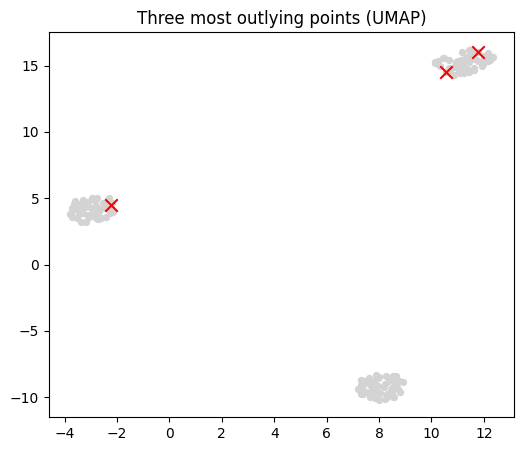

In [15]:
from scipy.spatial.distance import cdist
centres = np.array([X[y == g].mean(axis=0) for g in np.unique(y)])
dist_to_nearest = cdist(X, centres).min(axis=1)
worst = np.argsort(dist_to_nearest)[::-1][:3]
print('Most outlying points (index, distance):')
for i in worst:
    print(f'  point {i}: {dist_to_nearest[i]:.1f}')

plt.figure(figsize=(6, 5))
plt.scatter(u[:, 0], u[:, 1], c='lightgrey', s=18)
plt.scatter(u[worst, 0], u[worst, 1], c='red', s=80, marker='x')
plt.title('Three most outlying points (UMAP)'); plt.show()
# === TO BUILD: trace each flagged point back to its source: real rare form,
#     or a digitization/segmentation error? ===

## 10. Your real features

> 🔧 *TO BUILD*: point `X` and `y` at your own data: sign-shape features from Day 4, or vowel formants from Day 5. The same four pictures then describe hands, periods, or dialects.

## 11. Working with real data: hieratic signs

Everything so far ran on invented data with clean clusters, so we could check the methods against a known answer. Here is the same toolkit on a real problem, reproducing Figure 7 of [Tabin et al. (2023), *Collaborative Annotation and Computational Analysis of Hieratic*](https://raw.githubusercontent.com/christiancasey/measuring-manuscripts/refs/heads/main/Workbook/Day%207%E2%80%94Visualization/Tabin%20et%20al%20%282023%29%20Collaborative%20Annotation%20and%20Computational%20Analysis%20of%20Hieratic.pdf).

*Hieratic* is the cursive handwriting of ancient Egypt, and a single sign was drawn many different ways. We take one sign, 𓅓 (G17), as written in two Middle Egyptian texts (the *Shipwrecked Sailor* and the *Eloquent Peasant*, manuscript B1), turn every drawn instance into a row of numbers, and project them to two dimensions with PCA. Color marks the text.

NB Fetching the couple of hundred little pictures takes up to a minute.

In [ ]:
import io, csv, urllib.request
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

BASE  = ('https://raw.githubusercontent.com/christiancasey/measuring-manuscripts/'
         'refs/heads/main/Workbook/Day%207%E2%80%94Visualization/Isut/')
G17   = 'U+13153'                               # Gardiner G17, the owl 𓅓
TEXTS = ['Peasant B1', 'Shipwrecked']
FOLDER = {'Peasant B1': 'PeasantB1', 'Shipwrecked': 'Shipwrecked'}

def fetch(url):
    return urllib.request.urlopen(url).read()

def url_for(image_path):
    if image_path.startswith('texts/'):     # the tables predate the folder's rename to 'Isut'
        image_path = image_path[len('texts/'):]
    return BASE + image_path

def load_sign(text_folder, unicode_key, size=48):
    csv_text = fetch(BASE + text_folder + '/overlay_output/all_colored_signs.csv').decode('utf-8')
    rows = [r for r in csv.DictReader(io.StringIO(csv_text)) if r['unicode_key'] == unicode_key]
    vectors, crops = [], []
    for r in rows:
        im   = Image.open(io.BytesIO(fetch(url_for(r['image_path'])))).convert('RGBA')
        gray = Image.alpha_composite(Image.new('RGBA', im.size, (255, 255, 255, 255)), im).convert('L')
        w, h = gray.size
        s = max(w, h)
        square = Image.new('L', (s, s), 255)
        square.paste(gray, ((s - w) // 2, (s - h) // 2))
        small = square.resize((size, size))
        crops.append(small)
        vectors.append(255.0 - np.asarray(small, dtype=float))
    return np.array([v.ravel() for v in vectors]) / 255.0, crops

Xh, text_labels, crops = [], [], []
for name in TEXTS:
    print(f'fetching {name} ...')
    V, C = load_sign(FOLDER[name], G17)
    Xh.append(V); crops += C; text_labels += [name] * len(V)
    print(f'  {name}: {len(V)} instances of G17')
Xh = np.vstack(Xh)
text_labels = np.array(text_labels)
print('feature matrix:', Xh.shape)

A few of the owls from each text. Even by eye, they are not all the same shape.

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(11, 2.8))
for row, name in enumerate(TEXTS):
    idx = [i for i, l in enumerate(text_labels) if l == name][:10]
    for col, ax in enumerate(axes[row]):
        ax.axis('off')
        if col < len(idx):
            ax.imshow(crops[idx[col]], cmap='gray')
    axes[row, 0].set_title(name, loc='left', fontsize=9)
plt.tight_layout(); plt.show()

**Figure 7.** PCA finds the two directions of greatest variation among the owl shapes, and color marks the text. The thumbnails show the actual glyph at the most extreme points, the way Isut shows a sign when you hover over its dot. The owls at opposite ends are visibly different forms.

In [ ]:
Zh = PCA(n_components=2).fit_transform(Xh - Xh.mean(0))

fig, ax = plt.subplots(figsize=(8, 7))
color = {'Shipwrecked': '#7a2630', 'Peasant B1': '#27408b'}
for name in TEXTS:
    m = text_labels == name
    ax.scatter(Zh[m, 0], Zh[m, 1], c=color[name], s=26, alpha=0.75, edgecolors='none', label=name)
for i in {Zh[:,0].argmin(), Zh[:,0].argmax(), Zh[:,1].argmin(), Zh[:,1].argmax()}:
    ax.add_artist(AnnotationBbox(OffsetImage(np.asarray(crops[i]), cmap='gray', zoom=0.7),
                                 (Zh[i, 0], Zh[i, 1]), frameon=True, pad=0.1))
ax.legend(); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('G17 (the owl) across two texts, PCA to 2D')
plt.tight_layout(); plt.show()

### The three forms

The paper reads three types out of this plot. Cluster the points with k-means and, for each group, show its most central owl and how the two texts split inside it. One group comes out heavily Shipwrecked, which is the paper's point: one form of the sign is found almost only there.

In [ ]:
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Zh)

fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.8))
print('Three forms of the owl, by k-means on the PCA coordinates:')
for c in range(3):
    m = km.labels_ == c
    total = int(m.sum())
    ship  = int(((text_labels == 'Shipwrecked') & m).sum())
    centre = Zh[m].mean(0)
    medoid = np.where(m)[0][np.argmin(((Zh[m] - centre) ** 2).sum(1))]
    axes[c].imshow(crops[medoid], cmap='gray'); axes[c].axis('off')
    axes[c].set_title(f'form {c}\n{ship/total:.0%} Shipwrecked', fontsize=9)
    print(f'  form {c}: {total:3} tokens, Shipwrecked {ship} ({ship/total:.0%})')
plt.tight_layout(); plt.show()

This is the day's whole method on real material. One sign, measured across two manuscripts, separates into recurring forms: two shared, and one nearly unique to a single text. That is the kind of cross-textual pattern visualization is for. To study another sign, set `G17` to a different Unicode codepoint and rerun.

### Talk it over
- Did the clusters survive PCA, UMAP, and t-SNE? Which view do you trust most?
- Pick an outlier. Real exception, or a digitization error, and how would you check?
- **Check-in:** what single image would make your finding clear at a glance?
- In section 11, one form of the owl turned up almost only in the Shipwrecked Sailor. What would you check before calling that a real scribal habit rather than an accident of the sample?